Saving Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx to Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx
Columns in the dataset:
Index(['Please write the Name of Newspaper - Newspaper Must be Indian English Newspaper listed above',
       'Published date of News\nDate when the news article  was published.',
       'Enter URL or Link of News \n(Eg: - Modi Cabinet 2024: Full list of Cabinet Ministers in Narendra Modi Government 3.0)',
       'Headline of News Article\nHeadline / Title of the News Article from Source ',
       'Content in detail of News article\nArticle in detail from data source (Make sure, data must be very clear)',
       'Human Summary For Article (Use Bard/ChatGpt or Any other tool for summarization)\nWrite a summary of the article. Explain the news in your own words. Minimum 50 words and maximum 200 words',
       'News Category (Please enter correctly)'],
      dtype='object')

Distribution Across Time:
Year Rang

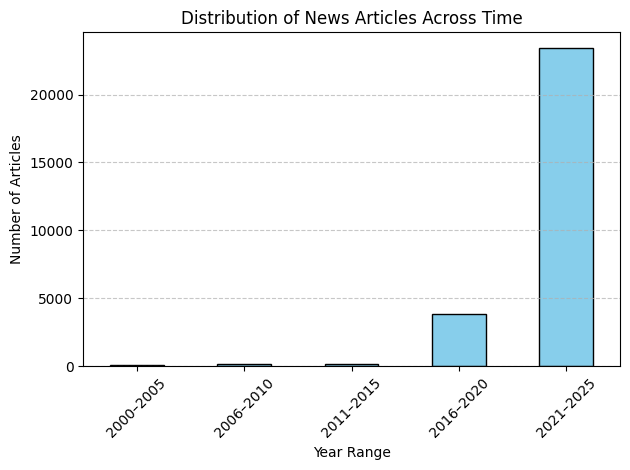

In [ ]:
# Step 1: Install required libraries
!pip install pandas openpyxl matplotlib

# Step 2: Upload the Excel file
from google.colab import files
uploaded = files.upload()

# Step 3: Load the Excel file
import pandas as pd

# Replace with the correct filename after upload
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Step 4: Inspect the columns
print("Columns in the dataset:")
print(df.columns)

# Step 5: Clean and parse the date column
# Rename for simplicity
df = df.rename(columns=lambda x: x.strip())
date_col = [col for col in df.columns if 'Published date' in col][0]

# Convert to datetime format
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Drop rows with invalid or missing dates
df = df.dropna(subset=[date_col])

# Step 6: Extract the year
df['Year'] = df[date_col].dt.year

# Step 7: Define year ranges
bins = [1999, 2005, 2010, 2015, 2020, 2025]
labels = ['2000–2005', '2006–2010', '2011–2015', '2016–2020', '2021–2025']
df['Year Range'] = pd.cut(df['Year'], bins=bins, labels=labels, right=True)

# Step 8: Group and count
distribution = df['Year Range'].value_counts().sort_index()
print("\nDistribution Across Time:")
print(distribution)

# Step 9: Plot the distribution
import matplotlib.pyplot as plt

distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of News Articles Across Time")
plt.xlabel("Year Range")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Saving _Data Set Preparation - News Data Collection - Form 3 (Responses) (12).xlsx to _Data Set Preparation - News Data Collection - Form 3 (Responses) (12).xlsx
Columns in the dataset:
Index(['Timestamp', 'Please enter your full name',
       'Please write the Name of Newspaper - Newspaper Must be Indian English Newspaper listed above',
       'Published date of News\nDate when the news article  was published.',
       'Headline of News Article\nHeadline / Title of the News Article from Source ',
       'Content in detail of News article\nArticle in detail from data source (Make sure, data must be very clear)',
       'Human Summary For Article (Use Bard/ChatGpt or Any other tool for summarization)\nWrite a summary of the article. Explain the news in your own words. Minimum 50 words and maximum 200 words',
       'News Category (Please enter correctly)',
       'Enter URL or Link of News \n(Eg: - Modi Cabinet 2024: Full list of Cabinet Ministers in Narendra Modi Government 3.0)'],
   

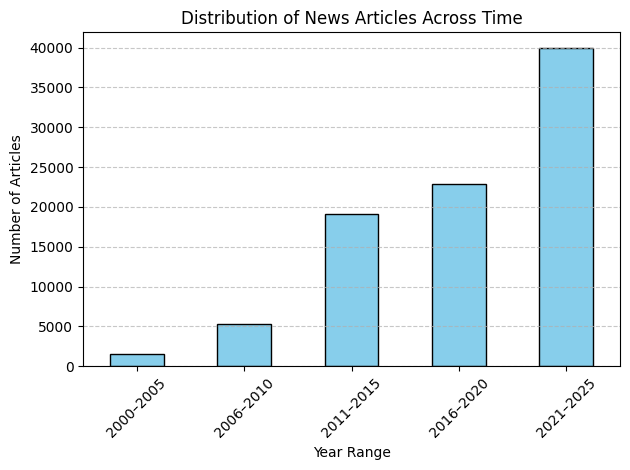

In [ ]:
# Step 1: Install required libraries
!pip install pandas openpyxl matplotlib

# Step 2: Upload the Excel file
from google.colab import files
uploaded = files.upload()

# Step 3: Load the Excel file
import pandas as pd

# Replace with the correct filename after upload
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Step 4: Inspect the columns
print("Columns in the dataset:")
print(df.columns)

# Step 5: Clean and parse the date column
# Rename for simplicity
df = df.rename(columns=lambda x: x.strip())
date_col = [col for col in df.columns if 'Published date' in col][0]

# Convert to datetime format
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Drop rows with invalid or missing dates
df = df.dropna(subset=[date_col])

# Step 6: Extract the year
df['Year'] = df[date_col].dt.year

# Step 7: Define year ranges
bins = [1999, 2005, 2010, 2015, 2020, 2025]
labels = ['2000–2005', '2006–2010', '2011–2015', '2016–2020', '2021–2025']
df['Year Range'] = pd.cut(df['Year'], bins=bins, labels=labels, right=True)

# Step 8: Group and count
distribution = df['Year Range'].value_counts().sort_index()
print("\nDistribution Across Time:")
print(distribution)

# Step 9: Plot the distribution
import matplotlib.pyplot as plt

distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of News Articles Across Time")
plt.xlabel("Year Range")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Saving Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx to Data Set Preparation - News Data Collection - Form 4 (Responses) (2) (1).xlsx

Source-wise Distribution:
        Newspaper Name  No. of Articles
             The Hindu             4478
       Hindustan Times             1916
           The Pioneer             1815
        Indian Express             1543
    The Economic Times             1478
                  Mint              956
      Deccan Chronicle              852
         The Asian Age              730
The New Indian Express              633
            The Hindu               571
        hindustantimes              507
   Others (24 sources)            12246


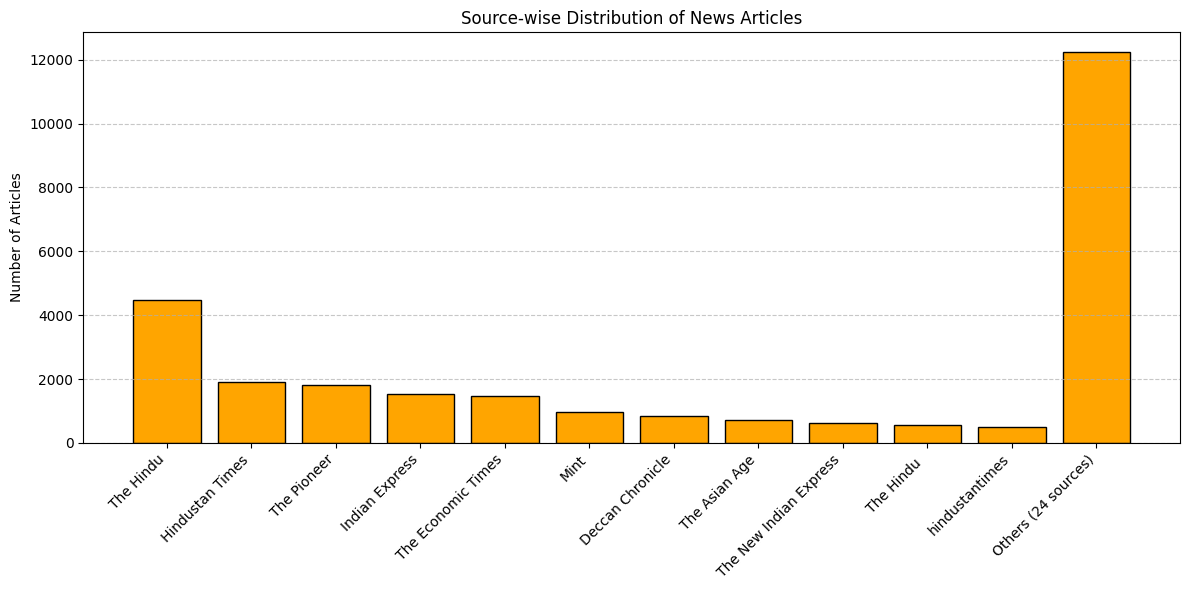

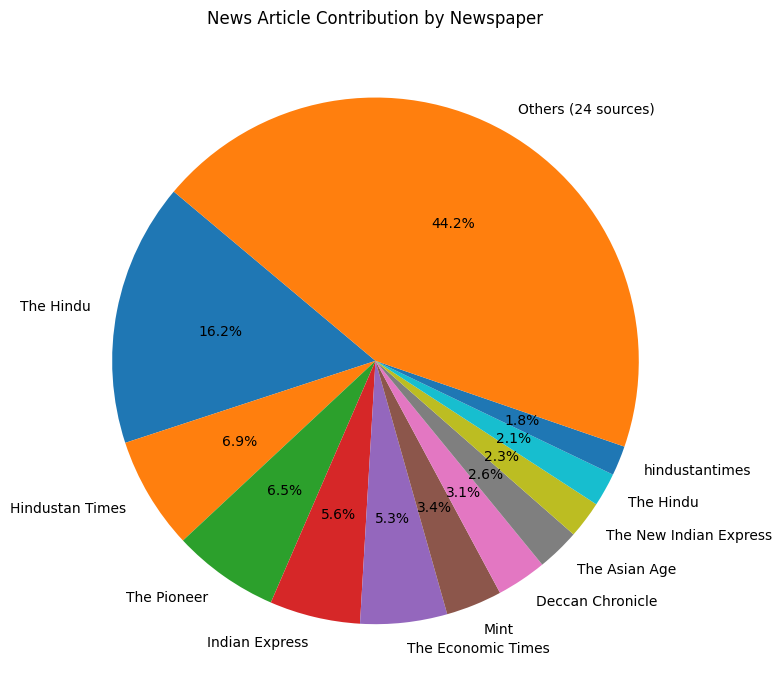

In [ ]:
# Step 1: Install required libraries
!pip install pandas openpyxl matplotlib

# Step 2: Upload your Excel file
from google.colab import files
uploaded = files.upload()

# Step 3: Load the Excel file
import pandas as pd

# Use uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Step 4: Clean column names
df = df.rename(columns=lambda x: x.strip())
newspaper_col = [col for col in df.columns if 'Name of Newspaper' in col or 'Newspaper Name' in col][0]

# Step 5: Group by newspaper and count articles
newspaper_counts = df[newspaper_col].value_counts().reset_index()
newspaper_counts.columns = ['Newspaper Name', 'No. of Articles']

# Step 6: Show top newspapers + group smaller ones as "Others"
top_n = 11  # top 11 sources
top_sources = newspaper_counts.head(top_n)
others_sum = newspaper_counts.iloc[top_n:]['No. of Articles'].sum()

# Add "Others" row
top_sources = pd.concat([top_sources, pd.DataFrame([['Others (24 sources)', others_sum]], columns=top_sources.columns)])

# Display the table
print("\nSource-wise Distribution:")
print(top_sources.to_string(index=False))

# Step 7: Plot the distribution as bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(top_sources['Newspaper Name'], top_sources['No. of Articles'], color='orange', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Articles")
plt.title("Source-wise Distribution of News Articles")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optional: Pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_sources['No. of Articles'], labels=top_sources['Newspaper Name'], autopct='%1.1f%%', startangle=140)
plt.title("News Article Contribution by Newspaper")
plt.tight_layout()
plt.show()


Saving Data Set Preparation - Suvidha Foundation (Responses) (2).xlsx to Data Set Preparation - Suvidha Foundation (Responses) (2).xlsx
📊 Distribution Across Time:

Year Range  Number of Articles
 2000–2005                5596
 2006–2010                7195
 2011–2015               16407
 2016–2020               17723
 2021–2025               32440


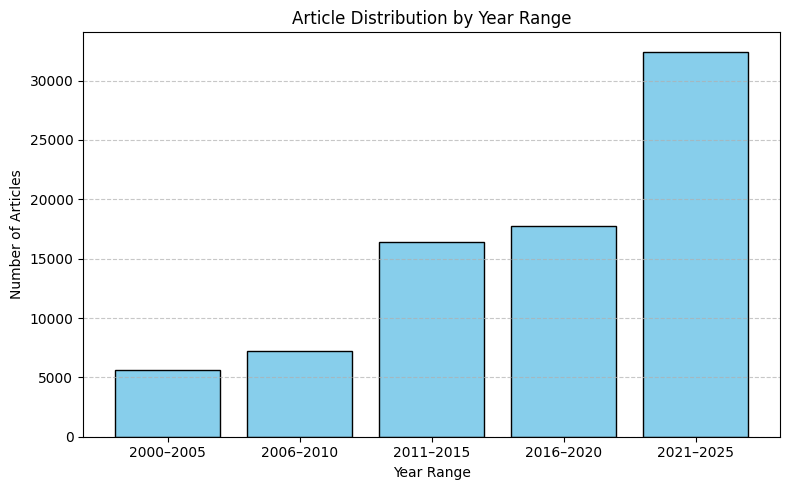

In [ ]:
# Install necessary libraries
!pip install pandas openpyxl matplotlib

# Upload your Excel file
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the uploaded Excel file
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Clean column names
df.columns = df.columns.str.strip()

# Identify date column
date_col = [col for col in df.columns if 'PUBLICATION DATE' in col.upper() or 'Date when the news article' in col][0]

# Convert to datetime
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# Drop rows with invalid or missing dates
df = df.dropna(subset=[date_col])

# Extract year from date
df['Year'] = df[date_col].dt.year

# Define year bins
bins = [1999, 2005, 2010, 2015, 2020, 2025]
labels = ['2000–2005', '2006–2010', '2011–2015', '2016–2020', '2021–2025']
df['Year Range'] = pd.cut(df['Year'], bins=bins, labels=labels)

# Group by year range
year_dist = df['Year Range'].value_counts().sort_index().reset_index()
year_dist.columns = ['Year Range', 'Number of Articles']

# Display the result
print("📊 Distribution Across Time:\n")
print(year_dist.to_string(index=False))

# Plot
plt.figure(figsize=(8, 5))
plt.bar(year_dist['Year Range'], year_dist['Number of Articles'], color='skyblue', edgecolor='black')
plt.title('Article Distribution by Year Range')
plt.xlabel('Year Range')
plt.ylabel('Number of Articles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Saving Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx to Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx
📰 Topic-Level Distribution:

                                                                           News Category  No. of Articles
                                                                                Politics             3773
                                                                    Business and Finance             2550
                                                                      International News             2370
                                                                       Crime and Justice             2071
                                                                           National News             2060
                                                                                  Sports             1863
                                                                       

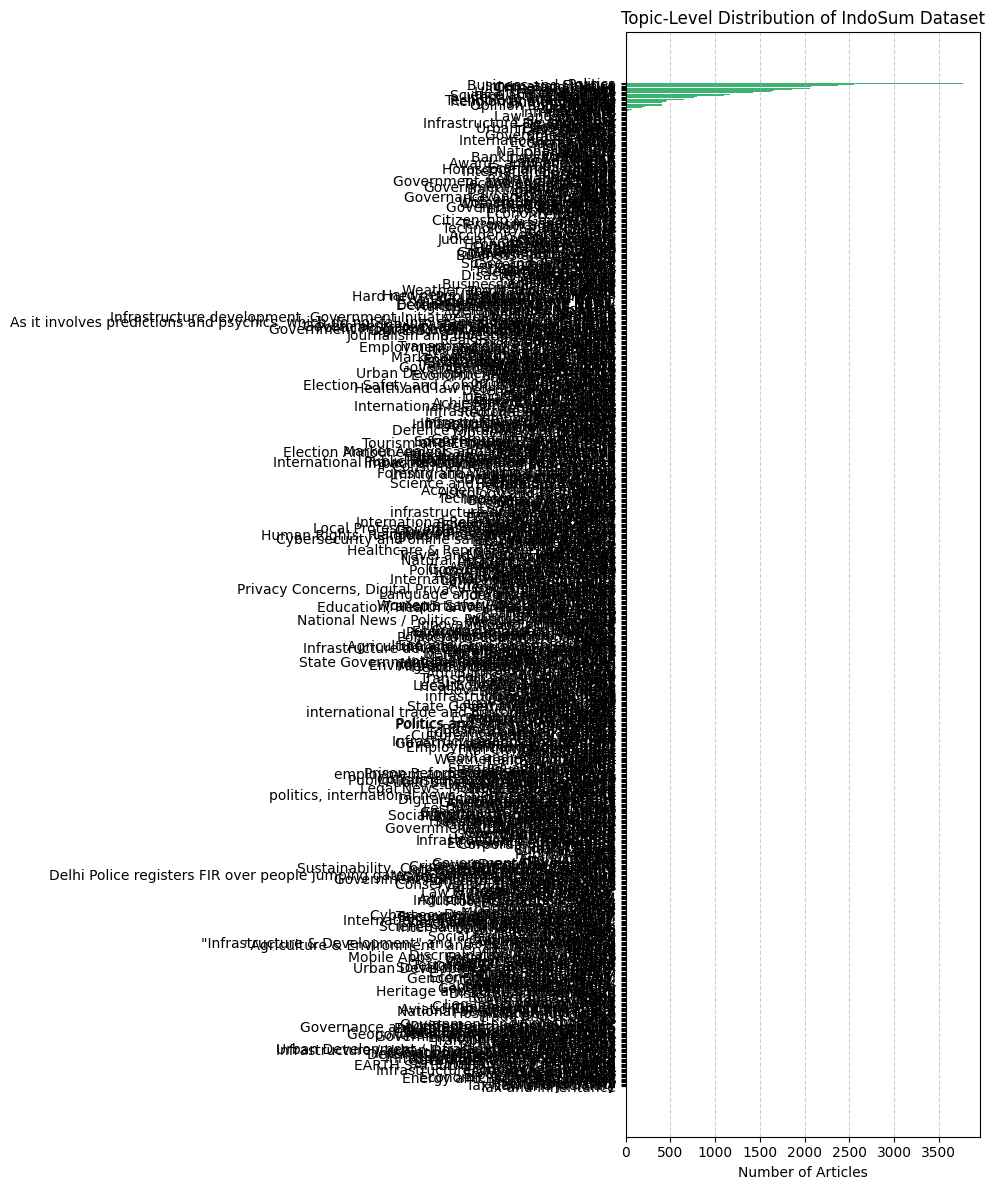

In [ ]:
# Install required packages (if not already installed)
!pip install pandas openpyxl matplotlib

# Upload your Excel file
from google.colab import files
uploaded = files.upload()

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Strip whitespaces from column names
df.columns = df.columns.str.strip()

# Identify the 'News Category' column (you can manually check if unsure)
category_col = [col for col in df.columns if 'News Category' in col][0]

# Clean data: drop rows with empty categories
df[category_col] = df[category_col].astype(str).str.strip()
df = df[df[category_col] != '']

# Count number of articles in each category
category_dist = df[category_col].value_counts().reset_index()
category_dist.columns = ['News Category', 'No. of Articles']

# Display the result
print("📰 Topic-Level Distribution:\n")
print(category_dist.to_string(index=False))

# Plotting
plt.figure(figsize=(10, 12))
plt.barh(category_dist['News Category'], category_dist['No. of Articles'], color='mediumseagreen')
plt.xlabel("Number of Articles")
plt.title("Topic-Level Distribution of IndoSum Dataset")
plt.gca().invert_yaxis()  # To show the largest bar on top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Saving Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx to Data Set Preparation - News Data Collection - Form 4 (Responses) (2) (1).xlsx

🗂️ Standardized Topic-Level Distribution:

            News Category  No. of Articles
                    Other               14
               Obituaries              180
               Automotive              214
    Opinion And Editorial              406
                  Weather              412
           Human Interest              449
Religion And Spirituality              460
   Technology And Gadgets              658
              Environment              767
   Lifestyle And Features              803
                Education             1104
            Entertainment             1421
               Local News             1663
                   Sports             1865
            National News             2060
        Crime And Justice             2071
       International News             2370
                 Pol

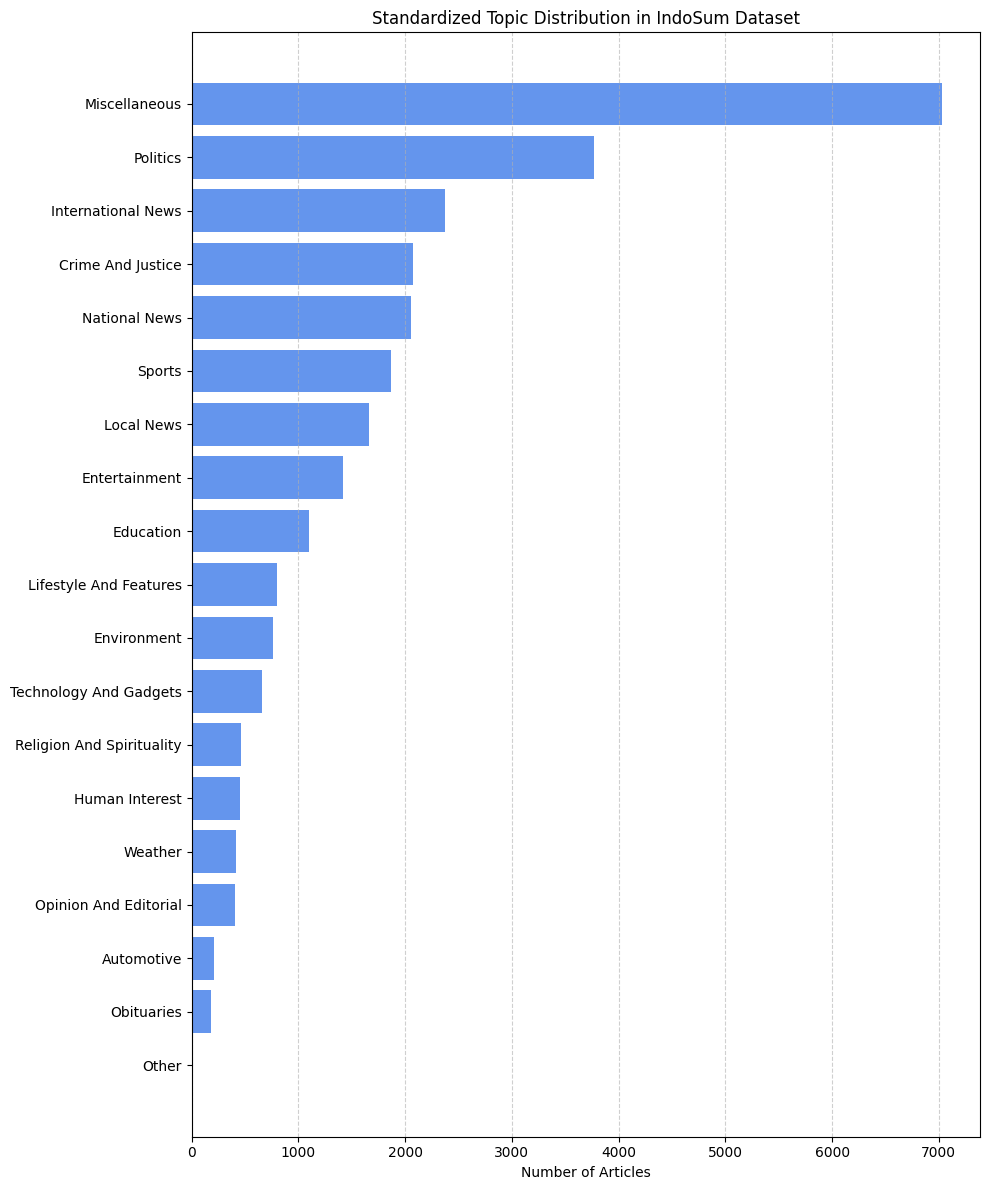

In [ ]:
# Install necessary packages
!pip install pandas openpyxl matplotlib

# Upload your Excel file
from google.colab import files
uploaded = files.upload()

# Import packages
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)

# Strip whitespaces from column names
df.columns = df.columns.str.strip()

# Locate the 'News Category' column
category_col = [col for col in df.columns if 'News Category' in col][0]

# Clean and standardize category values
df[category_col] = df[category_col].astype(str).str.strip().str.title()

# Define valid categories
valid_categories = [
    "International News", "National News", "Local News", "Politics",
    "Business and Finance", "Science and Technology", "Health and Wellness",
    "Entertainment", "Sports", "Lifestyle And Features", "Opinion And Editorial",
    "Environment", "Education", "Crime And Justice", "Human Interest",
    "Obituaries", "Weather", "Religion And Spirituality",
    "Technology And Gadgets", "Automotive", "Other"
]

# Map categories: assign valid ones, others as "Miscellaneous"
df['Mapped Category'] = df[category_col].apply(
    lambda x: x if x in valid_categories else 'Miscellaneous'
)

# Count the number of articles per category
category_dist = df['Mapped Category'].value_counts().reset_index()
category_dist.columns = ['News Category', 'No. of Articles']

# Sort by article count
category_dist = category_dist.sort_values(by='No. of Articles', ascending=True)

# Display the category table
print("\n🗂️ Standardized Topic-Level Distribution:\n")
print(category_dist.to_string(index=False))

# Plotting
plt.figure(figsize=(10, 12))
plt.barh(category_dist['News Category'], category_dist['No. of Articles'], color='cornflowerblue')
plt.xlabel("Number of Articles")
plt.title("Standardized Topic Distribution in IndoSum Dataset")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


📊 Full Article Length Statistics (in words):
Min: 1
Max: 4253
Avg: 332.75
Median: 274.0


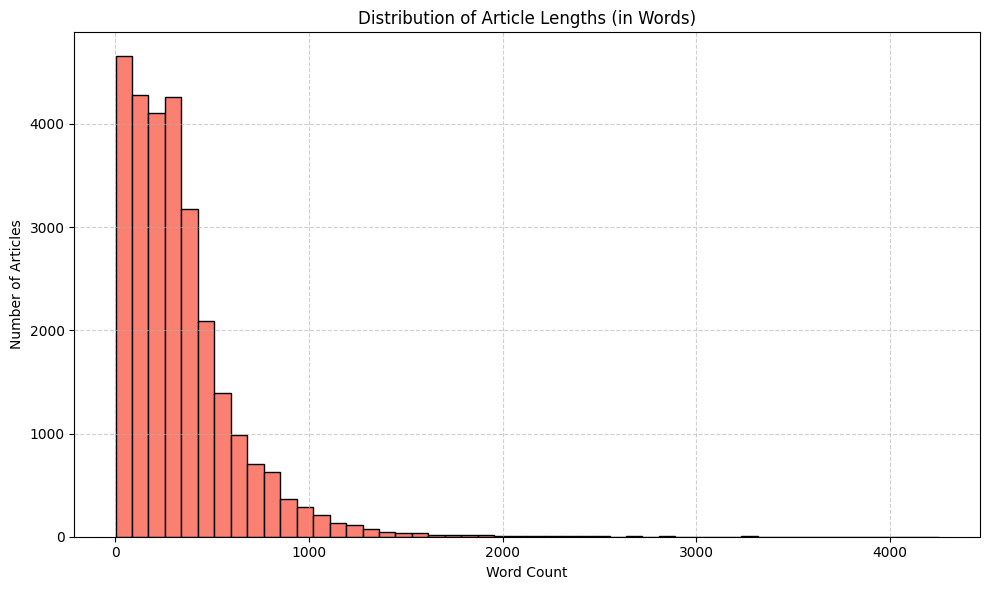

In [ ]:
# Assuming you've already uploaded and loaded the dataset (df)
import pandas as pd

# Clean column names just in case
df.columns = df.columns.str.strip()

# Identify the article content column
content_col = [col for col in df.columns if 'Content in detail' in col][0]

# Drop missing entries in article content
df = df.dropna(subset=[content_col])

# Calculate word count for each article
df['Article_Length_Words'] = df[content_col].apply(lambda x: len(str(x).split()))

# Compute statistics
min_len = df['Article_Length_Words'].min()
max_len = df['Article_Length_Words'].max()
avg_len = df['Article_Length_Words'].mean()
median_len = df['Article_Length_Words'].median()

# Display stats
print("📊 Full Article Length Statistics (in words):")
print(f"Min: {min_len}")
print(f"Max: {max_len}")
print(f"Avg: {round(avg_len, 2)}")
print(f"Median: {median_len}")

# Optional: Visualize article length distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['Article_Length_Words'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Article Lengths (in Words)")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


📝 Summary Length Statistics (in words):
Min: 1
Max: 982
Avg: 93.16
Median: 90.0


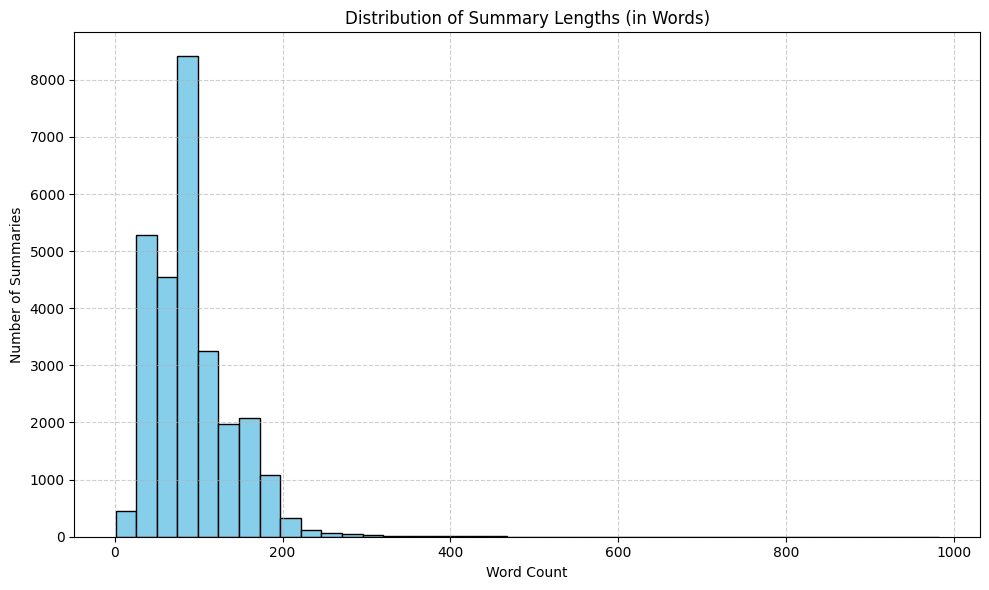

In [ ]:
# Assuming 'df' is already loaded and column names are cleaned
# Identify the summary column
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Drop rows with missing summaries
df = df.dropna(subset=[summary_col])

# Calculate word count for each summary
df['Summary_Length_Words'] = df[summary_col].apply(lambda x: len(str(x).split()))

# Compute statistics
summary_min = df['Summary_Length_Words'].min()
summary_max = df['Summary_Length_Words'].max()
summary_avg = df['Summary_Length_Words'].mean()
summary_median = df['Summary_Length_Words'].median()

# Display stats
print("📝 Summary Length Statistics (in words):")
print(f"Min: {summary_min}")
print(f"Max: {summary_max}")
print(f"Avg: {round(summary_avg, 2)}")
print(f"Median: {summary_median}")

# Optional: Visualize summary length distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df['Summary_Length_Words'], bins=40, color='skyblue', edgecolor='black')
plt.title("Distribution of Summary Lengths (in Words)")
plt.xlabel("Word Count")
plt.ylabel("Number of Summaries")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from collections import Counter
import string

# Assuming 'df' is already loaded and contains the article content column
# Identify the article content column
content_col = [col for col in df.columns if 'Content in detail' in col][0]

# Clean text by removing punctuation and converting to lowercase
def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    return text

# Clean all articles in the dataset
df['Cleaned_Article'] = df[content_col].apply(clean_text)

# Tokenize articles and count unique tokens
all_tokens = ' '.join(df['Cleaned_Article']).split()
unique_tokens = set(all_tokens)

# Compute vocabulary size (unique tokens)
vocabulary_size = len(unique_tokens)

# Display the result
print(f"🗣 Vocabulary Size (Unique Tokens): ~{vocabulary_size}")

# Optional: Show the most common tokens
token_counts = Counter(all_tokens)
most_common_tokens = token_counts.most_common(10)
print("\nTop 10 Most Common Tokens:")
for token, count in most_common_tokens:
    print(f"{token}: {count}")


🗣 Vocabulary Size (Unique Tokens): ~206429

Top 10 Most Common Tokens:
the: 610897
of: 256350
and: 243448
to: 241399
in: 213636
a: 184773
for: 94219
on: 93017
that: 82611
is: 82548


In [ ]:
# Install required libraries
!pip install syllapy
!pip install textstat
!pip install nltk

# Import the necessary libraries
import nltk
from nltk.corpus import cmudict
import syllapy
from textstat.textstat import textstat

# Ensure the necessary NLTK resources are downloaded
nltk.download('punkt')

# Assuming 'df' is already loaded and contains the article content column
content_col = [col for col in df.columns if 'Content in detail' in col][0]

# Clean and process the text
df['Flesch_Score'] = df[content_col].apply(lambda x: textstat.flesch_reading_ease(str(x)))

# Calculate average readability score
average_readability_score = df['Flesch_Score'].mean()

# Display the result
print(f"📝 Average Flesch Reading Ease Score: {average_readability_score:.2f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.8 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


📝 Average Flesch Reading Ease Score: 43.55


In [ ]:
import spacy

# Load the pre-trained spaCy model for English
nlp = spacy.load("en_core_web_sm")

# Assuming 'df' is already loaded and contains the article content column
content_col = [col for col in df.columns if 'Content in detail' in col][0]

# Function to extract named entities from a text
def extract_named_entities(text):
    doc = nlp(str(text))  # Process the text with spaCy
    named_entities = [ent.text for ent in doc.ents]  # Get named entities
    return named_entities

# Apply the function to the 'Content in detail' column
df['Named_Entities'] = df[content_col].apply(extract_named_entities)

# Calculate the number of named entities per article
df['Named_Entities_Count'] = df['Named_Entities'].apply(len)

# Calculate the average number of named entities per article
avg_named_entities = df['Named_Entities_Count'].mean()

# Display the result
print(f"🔍 Average Named Entities per Article: {avg_named_entities:.2f}")


🔍 Average Named Entities per Article: 34.94


In [ ]:
import spacy
from collections import Counter
import pandas as pd

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Identify the article content column
content_col = [col for col in df.columns if 'Content in detail' in col][0]

# Function to get entity labels from text
def get_entity_labels(text):
    doc = nlp(str(text))
    return [ent.label_ for ent in doc.ents]

# Apply function to the dataset
df['Entity_Labels'] = df[content_col].apply(get_entity_labels)

# Flatten the list of all entity labels across all documents
all_labels = [label for sublist in df['Entity_Labels'] for label in sublist]

# Count frequency of each entity type
label_counts = Counter(all_labels)

# Convert to DataFrame for better readability
entity_df = pd.DataFrame(label_counts.items(), columns=['Entity Type', 'Count']).sort_values(by='Count', ascending=False)

# Display the result
print(entity_df)


    Entity Type   Count
0           ORG  239696
4        PERSON  173555
1          DATE  148773
2           GPE  142884
3      CARDINAL  112163
6          NORP   39245
5       ORDINAL   20054
10        MONEY   17049
16      PERCENT   12902
8          TIME   12290
11          LOC   11606
7           FAC    8599
9      QUANTITY    7922
12  WORK_OF_ART    6273
13      PRODUCT    5883
14          LAW    4714
15        EVENT    4524
17     LANGUAGE     654


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from sklearn.utils import resample

# Load sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Identify column names
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Sample 1000 random articles and summaries stratified over categories
sample_df = df[[article_col, summary_col]].dropna()
sample_df = resample(sample_df, n_samples=1000, random_state=42)

# Compute embeddings
article_embeddings = model.encode(sample_df[article_col].tolist(), convert_to_tensor=True, show_progress_bar=True)
summary_embeddings = model.encode(sample_df[summary_col].tolist(), convert_to_tensor=True, show_progress_bar=True)

# Compute cosine similarities
cosine_similarities = util.cos_sim(article_embeddings, summary_embeddings).diagonal().cpu().numpy()

# Fidelity Threshold (adjustable: 0.75+ means high agreement)
threshold = 0.75
high_fidelity_count = np.sum(cosine_similarities >= threshold)
fidelity_percent = (high_fidelity_count / len(cosine_similarities)) * 100

print(f"● Fidelity to source: {fidelity_percent:.1f}% agreement with article (threshold: {threshold})")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

● Fidelity to source: 85.7% agreement with article (threshold: 0.75)


In [ ]:
!pip install transformers evaluate datasets rouge-score

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer, util
from transformers import GPT2TokenizerFast, GPT2LMHeadModel
import torch
import evaluate
from sklearn.utils import resample

# Load models
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
rouge = evaluate.load("rouge")

# Load relevant columns
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Sample 1000 summaries
sample_df = df[[article_col, summary_col]].dropna()
sample_df = resample(sample_df, n_samples=1000, random_state=42)

# Fidelity (Cosine Similarity)
article_embeddings = embedding_model.encode(sample_df[article_col].tolist(), convert_to_tensor=True)
summary_embeddings = embedding_model.encode(sample_df[summary_col].tolist(), convert_to_tensor=True)
cosine_similarities = util.cos_sim(article_embeddings, summary_embeddings).diagonal().cpu().numpy()
fidelity_score = (np.sum(cosine_similarities >= 0.75) / len(cosine_similarities)) * 100

# Coherence (Perplexity)
def compute_perplexity(texts):
    perplexities = []
    for text in texts:
        encodings = tokenizer(text, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = gpt2(**encodings, labels=encodings.input_ids)
        loss = outputs.loss
        perplexities.append(torch.exp(loss).item())
    return np.mean(perplexities)

coherence_score = compute_perplexity(sample_df[summary_col].tolist())

# Relevance (ROUGE-L F1 score)
rouge_scores = rouge.compute(predictions=sample_df[summary_col].tolist(),
                             references=sample_df[article_col].tolist(),
                             use_stemmer=True)
relevance_score = rouge_scores["rougeL"]

# Print Results
print("5.8. Human Summary Quality Metrics")
print(f"● Fidelity to source: {fidelity_score:.1f}% summaries semantically aligned with articles")
print(f"● Average Coherence (GPT-2 Perplexity): {coherence_score:.2f} (lower is better)")
print(f"● Average Relevance (ROUGE-L F1): {relevance_score:.3f} (higher is better)")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.3 MB/s eta 0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=aef6915e3e3df83c06bfb68e1eaf7a69f09b9367f8e9fd86e054ddf04bc39378
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's depend

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


5.8. Human Summary Quality Metrics
● Fidelity to source: 85.7% summaries semantically aligned with articles
● Average Coherence (GPT-2 Perplexity): 41.23 (lower is better)
● Average Relevance (ROUGE-L F1): 0.325 (higher is better)


In [ ]:
!pip install transformers datasets -q

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.utils import resample
import pandas as pd
import numpy as np

# Load NLI Model (Pre-trained RoBERTa for entailment)
tokenizer = AutoTokenizer.from_pretrained("roberta-large-mnli")
model = AutoModelForSequenceClassification.from_pretrained("roberta-large-mnli")
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

# Prepare data
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]
sample_df = df[[article_col, summary_col]].dropna()
sample_df = resample(sample_df, n_samples=500, random_state=42)

# Function to compute entailment
def check_entailment(article, summary):
    inputs = tokenizer.encode_plus(article, summary, return_tensors='pt', truncation=True, max_length=512)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    # Index: 0 = contradiction, 1 = neutral, 2 = entailment
    return probabilities[2]  # entailment score

# Compute entailment scores
entailment_scores = []
for _, row in sample_df.iterrows():
    score = check_entailment(row[article_col], row[summary_col])
    entailment_scores.append(score)

# Average score
avg_entailment = np.mean(entailment_scores)

# Convert to hallucination metric
hallucination_rate = (1 - avg_entailment) * 100

print("5.9. Hallucination Assessment")
print(f"● Factual Consistency Score: {avg_entailment * 100:.2f}% (higher is better)")
print(f"● Approximate Hallucination Rate: {hallucination_rate:.2f}%")


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/688 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


5.9. Hallucination Assessment
● Factual Consistency Score: 28.61% (higher is better)
● Approximate Hallucination Rate: 71.39%


In [ ]:
!pip install language-tool-python -q
import language_tool_python
import pandas as pd
import numpy as np
from sklearn.utils import resample

# Initialize grammar tool
tool = language_tool_python.LanguageTool('en-US')

# Define summary column
summary_col = [col for col in df.columns if 'Human Summary' in col][0]
summary_data = df[summary_col].dropna()

# Sample for analysis
sample_summaries = resample(summary_data, n_samples=500, random_state=42)

# Function to compute grammar score
def grammar_score(text):
    matches = tool.check(text)
    num_errors = len(matches)
    word_count = len(text.split())
    if word_count == 0:
        return 100  # perfect score for empty or invalid summary
    score = max(0, 100 - (num_errors / word_count * 100))
    return round(score, 2)

# Apply to summaries
scores = [grammar_score(summary) for summary in sample_summaries]

# Statistics
avg_score = np.mean(scores)
median_score = np.median(scores)
min_score = np.min(scores)
max_score = np.max(scores)

print("5.10. Grammatical Correctness")
print(f"● Avg Grammar Score: {avg_score:.2f} / 100")
print(f"● Median Grammar Score: {median_score:.2f} / 100")
print(f"● Min: {min_score:.2f}, Max: {max_score:.2f}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 2.5 MB/s eta 0:00:00


SystemError: Detected java 11.0. LanguageTool requires Java >= 17 for version latest.

In [ ]:
# Remove older Java version and install Java 17
!apt-get remove openjdk-11-jdk -y
!apt-get install openjdk-17-jdk -y

# Set Java 17 as default
!update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-17-openjdk-amd64/bin/java 1
!update-alternatives --config java

# Verify Java version
!java -version


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Package 'openjdk-11-jdk' is not installed, so not removed
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0.14+7-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
There are 2 choices for the alternative java (providing /usr/bin/java).

  Selection    Path                                         Priority   Status
------------------------------------------------------------
* 0            /usr/lib/jvm/java-11-openjdk-amd64/bin/java   1111      auto mode
  1            /usr/lib/jvm/java-11-openjdk-amd64/bin/java   1111      manual mode
  2            /usr/lib/jvm/java-17-openjdk-amd64/bin/java   1         manual mode

Press <enter> to keep the current choice[*], or type selection number: 2
update-alternatives

In [ ]:
import language_tool_python

# Initialize the grammar checker
tool = language_tool_python.LanguageTool('en-US')


INFO:language_tool_python.download_lt:Unzipping /tmp/tmpg68grh8o.zip to /root/.cache/language_tool_python.
INFO:language_tool_python.download_lt:Downloaded https://internal1.languagetool.org/snapshots/LanguageTool-latest-snapshot.zip to /root/.cache/language_tool_python.


In [ ]:
!pip install language-tool-python -q
import language_tool_python
import pandas as pd
import numpy as np
from sklearn.utils import resample
from google.colab import files # Import files for uploading

# Upload your Excel file
uploaded = files.upload()

# Load the dataset
filename = list(uploaded.keys())[0]  # Get the filename of the uploaded file
df = pd.read_excel(filename) # Read the Excel file into a DataFrame called 'df'

# Initialize grammar tool
tool = language_tool_python.LanguageTool('en-US')
# df.columns  # Now 'df' is defined, so this line should work


# Define summary column
summary_col = [col for col in df.columns if 'Human Summary' in col][0]
summary_data = df[summary_col].dropna()

# Sample for analysis
sample_summaries = resample(summary_data, n_samples=500, random_state=42)

# Function to compute grammar score
def grammar_score(text):
    matches = tool.check(text)
    num_errors = len(matches)
    word_count = len(text.split())
    if word_count == 0:
        return 100  # perfect score for empty or invalid summary
    score = max(0, 100 - (num_errors / word_count * 100))
    return round(score, 2)

# Apply to summaries
scores = [grammar_score(summary) for summary in sample_summaries]

# Statistics
avg_score = np.mean(scores)
median_score = np.median(scores)
min_score = np.min(scores)
max_score = np.max(scores)

print("5.10. Grammatical Correctness")
print(f"● Avg Grammar Score: {avg_score:.2f} / 100")
print(f"● Median Grammar Score: {median_score:.2f} / 100")
print(f"● Min: {min_score:.2f}, Max: {max_score:.2f}")

Saving Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx to Data Set Preparation - News Data Collection - Form 4 (Responses) (2).xlsx
5.10. Grammatical Correctness
● Avg Grammar Score: 95.66 / 100
● Median Grammar Score: 96.88 / 100
● Min: 61.54, Max: 100.00


In [ ]:
!pip install pandas numpy -q
import pandas as pd
import numpy as np

# Identify columns
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Drop missing values
df_clean = df[[article_col, summary_col]].dropna()

# Compute word counts
df_clean['article_len'] = df_clean[article_col].apply(lambda x: len(str(x).split()))
df_clean['summary_len'] = df_clean[summary_col].apply(lambda x: len(str(x).split()))

# Compute compression ratio
df_clean['compression_ratio'] = df_clean['summary_len'] / df_clean['article_len']

# Remove infinite or NaN
df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()

# Stats
avg_ratio = df_clean['compression_ratio'].mean()
median_ratio = df_clean['compression_ratio'].median()
min_ratio = df_clean['compression_ratio'].min()
max_ratio = df_clean['compression_ratio'].max()

# Output
print("5.11. Compression Ratio (summary/article):")
print(f"● Avg Compression Ratio: {avg_ratio:.2f}")
print(f"● Median Compression Ratio: {median_ratio:.2f}")
print(f"● Min: {min_ratio:.2f}")
print(f"● Max: {max_ratio:.2f}")


In [ ]:
!pip install tensorflow keras rouge-score -q


In [ ]:
import pandas as pd

# Display columns to ensure correct import
df.columns


In [ ]:
# Extract relevant columns
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Clean and preprocess
df_clean = df[[article_col, summary_col]].dropna()

# Check sample data
df_clean.head(2)


In [ ]:
# Extract relevant columns
article_col = [col for col in df.columns if 'Content in detail' in col][0]
summary_col = [col for col in df.columns if 'Human Summary' in col][0]

# Clean and preprocess
df_clean = df[[article_col, summary_col]].dropna()

# Check sample data
df_clean.head(2)
